In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

You really ought to real the Logistic Regression section before this...

# Neural Networks
A neural network is a type of ML model that is specifically modeled to learn similarly to how a brain does. Here are some of its components:
- Neurons (nodes): The basic processing units. Each neuron receives inputs, multiplies them by specific "weights" adds a "bias" and passes the result through an "activation function"
- Weights and Biases: The network's adjustable parameters. Weights determine the importance of an input, while biases help the network fine-tune the output
- Layers:
    - Input Layer: Receives the raw data
    - Hidden Layers: Perform complex computations to extract patterns and features
    - Output Layer: Produces the final prediction or classification

If you have read the Logistic Regression part of the Regression.ipynb some of this will be familiar to you. You can actually think about Logistic Regression as a single layer neural network.

## Activation function(s)
Well, choosing activation functions depends on your usecase. In this demonstration I will be testing this using classification. So as a result we will be using the ReLU activation functions for the hidden layers and then for the final one use sigmoid. As discussed before, Sigmoid is typically used to normalize outputs from $-\infty$ to $\infty$. ReLU is best for hidden layers because:
- ReLU outputs exactly zero for negative values, which kills neurons. This creates sparse activations, meaning only a fraction of the network is actively firing at any given time, leading to more efficient processing and less overfitting
- Functions like Sigmoid and Tanh have derivatives that squeeze outputs very close to zero, which slows down learning in deep networks. ReLU’s derivative is a constant 1 for all positive inputs, allowing gradients to flow freely and networks to train much faster

ReLU can be represented as: $$f(x)=\max(0,x)$$

## Loss function
Here we will use Cross Entropy Loss again for the same reason we did for Logistic Regression. It is best used for 2 class classification...

## Gradient Decent Derivatives
Gradient Decent is used to update our weights and biases through training to help our model actually learn. What we do next is called backpropigation, it represents the process of calculating the gradients for gradient descent to use later on. First we feedforward (run through the model as is) and then calculate the derivatives to update the weights and biases. Mathematically: $$\frac{\partial J(w)}{\partial w}=\frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w_j}$$
Where:
- $J$ is the loss function, the derivative is in terms of the true $y$ values
- $\hat{y}$ is the predicted $y$ value which can be represented as: $f(z)$
- $z$ is the weighted sum (the linear combination of inputs, weights, and bias before the activation function is applied): $$z=\sum(w_i\cdot x_i)+b$$

Where:
- $w_i$: weight at $i$th index
- $b$: bias
- $x_i$: data from previous stage at $i$th index

### Loss function derivative
We found this previously, but here it is again: We take the derivative of $L = -y \ln(\hat{y}) - (1 - y) \ln(1 - \hat{y})$ with respect to $\hat{y}$. Recall that $\frac{d}{dx}(\ln x) = \frac{1}{x}$.$$\frac{\partial L}{\partial \hat{y}} = - \left[ y \cdot \frac{1}{\hat{y}} + (1 - y) \cdot \frac{1}{1 - \hat{y}} \cdot (-1) \right]$$The $(-1)$ comes from the chain rule applied to the inner term $(1 - \hat{y})$. Simplifying the signs:$$\frac{\partial L}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1 - y}{1 - \hat{y}}$$Now, let's find a common denominator to combine these fractions:$$\frac{\partial L}{\partial \hat{y}} = \frac{-y(1 - \hat{y}) + \hat{y}(1 - y)}{\hat{y}(1 - \hat{y})}$$$$\frac{\partial L}{\partial \hat{y}} = \frac{-y + y\hat{y} + \hat{y} - y\hat{y}}{\hat{y}(1 - \hat{y})}$$The $y\hat{y}$ terms cancel perfectly, leaving:$$\frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$$

### Activation functions derivative
So we need both of the derivatives for ReLU and Sigmoid since both are being used. We have done Sigmoid in the past: It is easier to think of this as $\hat{y} = \sigma(z) = (1 + e^{-z})^{-1}$ first: $$\frac{\partial \hat{y}}{\partial z} = -1(1 + e^{-z})^{-2} \cdot \frac{d}{dz}(1 + e^{-z})$$$$\frac{\partial \hat{y}}{\partial z} = -1(1 + e^{-z})^{-2} \cdot (e^{-z} \cdot -1)$$The negatives cancel out:$$\frac{\partial \hat{y}}{\partial z} = \frac{e^{-z}}{(1 + e^{-z})^2}$$Now, we can rewrite this fraction strategically by splitting the denominator:$$\frac{\partial \hat{y}}{\partial z} = \left( \frac{1}{1 + e^{-z}} \right) \cdot \left( \frac{e^{-z}}{1 + e^{-z}} \right)$$Notice that the first term is exactly $\hat{y}$. For the second term, we can add and subtract $1$ in the numerator:$$\frac{e^{-z}}{1 + e^{-z}} = \frac{1 + e^{-z} - 1}{1 + e^{-z}} = \frac{1 + e^{-z}}{1 + e^{-z}} - \frac{1}{1 + e^{-z}} = 1 - \hat{y}$$Substituting these back in gives us the classic property of the sigmoid derivative:$$\frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})$$

ReLU is pretty easy. When $z>0 \rightarrow f(z) = x$ so: $z>0 \rightarrow \frac{\partial f(z)}{\partial z} = 1$. For the $z < 0$ case the derivative is obviously $0$.

### Derivative of the weighted sum (weights and biases)
This one is also pretty easy. This takes the form of: $$z = w_1\cdot x_1 + w_2\cdot x_2 + ... + w_n\cdot x_n + b$$

So the partial derivative with respect to the weights is super trivial, it is literally just: $x_i$.
The partail derivative for bias instead is $1$

## Putting it all together

So the order in which everything calculated/multiplies goes as follows:
1. $\frac{\partial J}{\partial \hat{y}}$: derivative of loss is multiplied by
2. $\frac{\partial \hat{y}}{\partial z}$: derivative of sigmoid is multiplied by
3. Hidden layer derivatives, start from final to beginning
    4. Last weights and bias derivatives is multiplied by 
    5. ReLU derivative

Remember, we are going through the model backwards and each layer has its own set of weights and biases.

In [21]:
class NN:
    def __init__(self, input_size, hidden_size, learning_rate=0.01):
        self.alpha = learning_rate
        
        self.w1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        
        self.w2 = np.random.randn(hidden_size, 1) * 0.01
        self.b2 = np.zeros((1, 1))

        self.loss = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def relu(self, z):
        return np.maximum(0, z)

    def binary_cross_e(self, y_true, y_pred):
        m = len(y_true)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)   # Clip values to avoid log(0) numeric instability
        return -(1/m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))   # this 1/m term comes from the fact that we are using the form of binary cross entropy that is for multiple observations

    def forward(self, X):
        self.X = X

        self.z1 = np.dot(self.X, self.w1) + self.b1
        self.a1 = self.relu(self.z1)
        
        self.z2 = np.dot(self.a1, self.w2) + self.b2
        self.y_hat = self.sigmoid(self.z2)
        
        return self.y_hat

    def backward(self, y):
        m = y.shape[0]

        dz2 = self.y_hat - y   # remember from regression, derivatives of the loss and sigmoid reduce to this
        
        dw2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.w2.T)

        dz1 = da1 * (self.z1 > 0)
        
        dw1 = np.dot(self.X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Param updates
        self.w2 -= self.alpha * dw2
        self.b2 -= self.alpha * db2
        self.w1 -= self.alpha * dw1
        self.b1 -= self.alpha * db1

    def train(self, X, y, epochs = 100):
        for e in range(epochs):
            y_hat = self.forward(X)

            loss = self.binary_cross_e(y, y_hat)
            self.loss.append(loss)

            self.backward(y)

            if e % 10 == 0:
                print(f"Epoch {e:4d} | Loss: {loss:.4f}")
                
        return self.loss

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)
        

In [26]:
data = load_breast_cancer()
X, y = data.data, data.target.reshape(-1, 1)

X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1234
)

model = NN(input_size=X_train.shape[1], hidden_size=4, learning_rate=0.1)
loss = model.train(X_train, y_train, epochs = 200)

Epoch    0 | Loss: 0.6933
Epoch   10 | Loss: 0.6787
Epoch   20 | Loss: 0.6691
Epoch   30 | Loss: 0.6597
Epoch   40 | Loss: 0.6414
Epoch   50 | Loss: 0.5881
Epoch   60 | Loss: 0.4597
Epoch   70 | Loss: 0.3097
Epoch   80 | Loss: 0.2182
Epoch   90 | Loss: 0.1681
Epoch  100 | Loss: 0.1382
Epoch  110 | Loss: 0.1189
Epoch  120 | Loss: 0.1055
Epoch  130 | Loss: 0.0956
Epoch  140 | Loss: 0.0879
Epoch  150 | Loss: 0.0812
Epoch  160 | Loss: 0.0746
Epoch  170 | Loss: 0.0695
Epoch  180 | Loss: 0.0654
Epoch  190 | Loss: 0.0620


Text(0, 0.5, 'Loss')

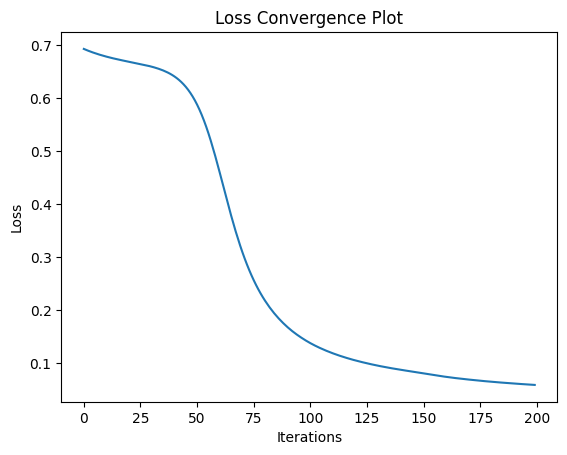

In [27]:
plt.plot(loss)
plt.title("Loss Convergence Plot")
plt.xlabel("Iterations")
plt.ylabel("Loss")

In [30]:
# Making predictions
y_preds = model.predict(X_test)

# Raw accuracy percent
accuracy = np.mean(y_preds == y_test)
print(f"Model Accuracy: {accuracy:.2f}")

cm = confusion_matrix(np.array(y_test), np.array(y_preds))
print(f"Confusion Matrix:\n{cm}")

Model Accuracy: 0.96
Confusion Matrix:
[[40  5]
 [ 0 69]]


# Optimizers
Sometimes your model might need an extra push to converge, that might mean that you need to improve your optimizer. Gradient Descent is a type of optimzer which most of the more robust ones are built off of. The most common one these days is the Adam optimizer. It is so great because it takes from other older algorithms such as Momentum (accelerates convergence in flatter regions) and RMSProp (changing our step size dynamically based on how steep the terrain is).

## Adam Optimizer
This alogirthm works by tracking two running averages for every single parameter (weight/bias) in the network:
- $m$ (The First Moment): Tracks the average direction and speed (like Momentum)
- $v$ (The Second Moment): Tracks the average variance or volatility (like RMSprop).

To calculate $m$ we solve: $$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t$$
Where:
- $g_t$: Gradient from GD before
- $\beta_1$: Momentum parameter

To calculate $v$ we solve $$\mathbf{v}_t = \beta_2 \mathbf{v}_{t-1} + (1 - \beta_2)\mathbf{g}_t^2$$
- $\beta_2$: volitility parameter

Since both $m_t$ and $v_t$ v 
t
​
  are initialized at zero, they tend to be biased toward zero, especially during the initial steps. To correct this bias, Adam computes the bias-correct: $$\hat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1 - \beta_1^t} \quad \text{and} \quad \hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_2^t}$$

So the final weight update is: $$w_t = w_{t-1} - \frac{\alpha}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} \hat{\mathbf{m}}_t$$ed estimates

In [31]:
class AdamOptimizer:
    def __init__(self, learning_rate=0.0025, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None
        self.v = None
        self.t = 0

    def update(self, params, grads):
        if self.m is None:
            self.m = [np.zeros_like(param) for param in params]
        if self.v is None:
            self.v = [np.zeros_like(param) for param in params]

        self.t += 1
        updated_params = []
        
        for i, (param, grad) in enumerate(zip(params, grads)):
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad
            
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad ** 2)
            
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)
            
            param_update = param - self.learning_rate * m_hat / (np.sqrt(v_hat) + self.epsilon)
            updated_params.append(param_update)

        return updated_params

In [34]:
class NN_Adam:
    def __init__(self, input_size, hidden_size, learning_rate=0.01):
        self.alpha = learning_rate
        
        self.w1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        
        self.w2 = np.random.randn(hidden_size, 1) * 0.01
        self.b2 = np.zeros((1, 1))

        self.loss = []
        self.optimizer = AdamOptimizer(learning_rate=learning_rate)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def relu(self, z):
        return np.maximum(0, z)

    def binary_cross_e(self, y_true, y_pred):
        m = len(y_true)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)   # Clip values to avoid log(0) numeric instability
        return -(1/m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))   # this 1/m term comes from the fact that we are using the form of binary cross entropy that is for multiple observations

    def forward(self, X):
        self.X = X

        self.z1 = np.dot(self.X, self.w1) + self.b1
        self.a1 = self.relu(self.z1)
        
        self.z2 = np.dot(self.a1, self.w2) + self.b2
        self.y_hat = self.sigmoid(self.z2)
        
        return self.y_hat

    def backward(self, y):
        m = y.shape[0]

        dz2 = self.y_hat - y   # remember from regression, derivatives of the loss and sigmoid reduce to this
        
        dw2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.w2.T)

        dz1 = da1 * (self.z1 > 0)
        
        dw1 = np.dot(self.X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        params = [self.w1, self.b1, self.w2, self.b2]
        grads = [dw1, db1, dw2, db2]

        updated = self.optimizer.update(params, grads)
        
        self.w1, self.b1, self.w2, self.b2 = updated

    def train(self, X, y, epochs = 100):
        for e in range(epochs):
            y_hat = self.forward(X)

            loss = self.binary_cross_e(y, y_hat)
            self.loss.append(loss)

            self.backward(y)

            if e % 10 == 0:
                print(f"Epoch {e:4d} | Loss: {loss:.4f}")
                
        return self.loss

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

In [37]:
model = NN_Adam(input_size=X_train.shape[1], hidden_size=4, learning_rate=0.1)
loss = model.train(X_train, y_train, epochs = 60)

Epoch    0 | Loss: 0.6933
Epoch   10 | Loss: 0.0479
Epoch   20 | Loss: 0.0309
Epoch   30 | Loss: 0.0205
Epoch   40 | Loss: 0.0124
Epoch   50 | Loss: 0.0084


Text(0, 0.5, 'Loss')

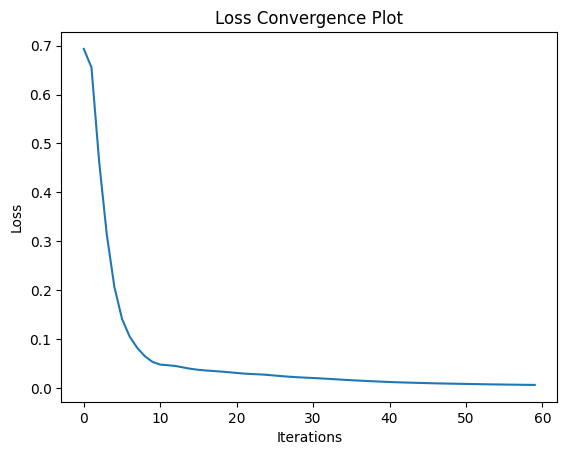

In [38]:
plt.plot(loss)
plt.title("Loss Convergence Plot")
plt.xlabel("Iterations")
plt.ylabel("Loss")

In [39]:
# Making predictions
y_preds = model.predict(X_test)

# Raw accuracy percent
accuracy = np.mean(y_preds == y_test)
print(f"Model Accuracy: {accuracy:.2f}")

cm = confusion_matrix(np.array(y_test), np.array(y_preds))
print(f"Confusion Matrix:\n{cm}")

Model Accuracy: 0.97
Confusion Matrix:
[[42  3]
 [ 0 69]]


Notice how the model converges way quicker while also keeping similar accuracy? That is why Adam's optimizer is so good.